# CKA Analysis: Pretrained Embeddings vs ADMET Labels

Compares graph-level embeddings from GPS++ 800M models pretrained on different datasets
against all 22 ADMET benchmark task labels.

**Uni-modal**: toymix, dti, rxrx3, largemix  
**Multi-modal**: toymix_dti, toymix_rxrx3, toymix_bbbc047, rxrx3_dti, toymix_rxrx3_dti, largemix_dti

**Prerequisites**: Run `python scripts/cka_analysis.py` first.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

matplotlib.rcParams.update({"font.size": 11, "figure.dpi": 120})
sns.set_style("whitegrid")

RESULTS_PATH = "../results/cka_analysis/cka_results.csv"
df = pd.read_csv(RESULTS_PATH)
print(f"Loaded {len(df)} rows, {df['checkpoint'].nunique()} checkpoints, "
      f"{df['task'].nunique()} tasks")
df.head()

Loaded 462 rows, 11 checkpoints, 22 tasks


,checkpoint,modality,task,category,task_type,embedding,linear_cka,kernel_cka,n_molecules
0,data,none,caco2_wang,Absorption,regression,data,0.063275,0.073761,910
1,data,none,hia_hou,Absorption,classification,data,0.100659,0.096503,578
2,data,none,pgp_broccatelli,Absorption,classification,data,0.116208,0.178948,1218
3,data,none,bioavailability_ma,Absorption,classification,data,0.032353,0.035681,640
4,data,none,lipophilicity_astrazeneca,Absorption,regression,data,0.047549,0.041218,4200


In [2]:
from notebook_utils import ADMET_TASK_ORDER as TASK_ORDER, TASK_CATEGORY

CKPT_UNI = ["toymix", "dti", "rxrx3", "largemix"]
CKPT_MULTI = ["toymix_dti", "toymix_rxrx3", "toymix_bbbc047",
              "rxrx3_dti", "toymix_rxrx3_dti", "largemix_dti"]
CKPT_ALL = CKPT_UNI + CKPT_MULTI

CATEGORY_COLORS = {
    "Absorption": "#4C72B0", "Metabolism": "#DD8452",
    "Excretion": "#55A868", "Toxicity": "#C44E52",
}

# Separate data baseline from model results
df_data = df[df["checkpoint"] == "data"].copy()
df_model = df[df["checkpoint"] != "data"].copy()

task_to_cat = df_model.set_index("task")["category"].to_dict()

def color_yticks(ax):
    for label in ax.get_yticklabels():
        cat = task_to_cat.get(label.get_text(), "")
        label.set_color(CATEGORY_COLORS.get(cat, "black"))
        label.set_fontsize(9)


## 1. Full Heatmaps: All Checkpoints

CKA values across all 10 checkpoints (uni-modal + multi-modal) for each embedding type.

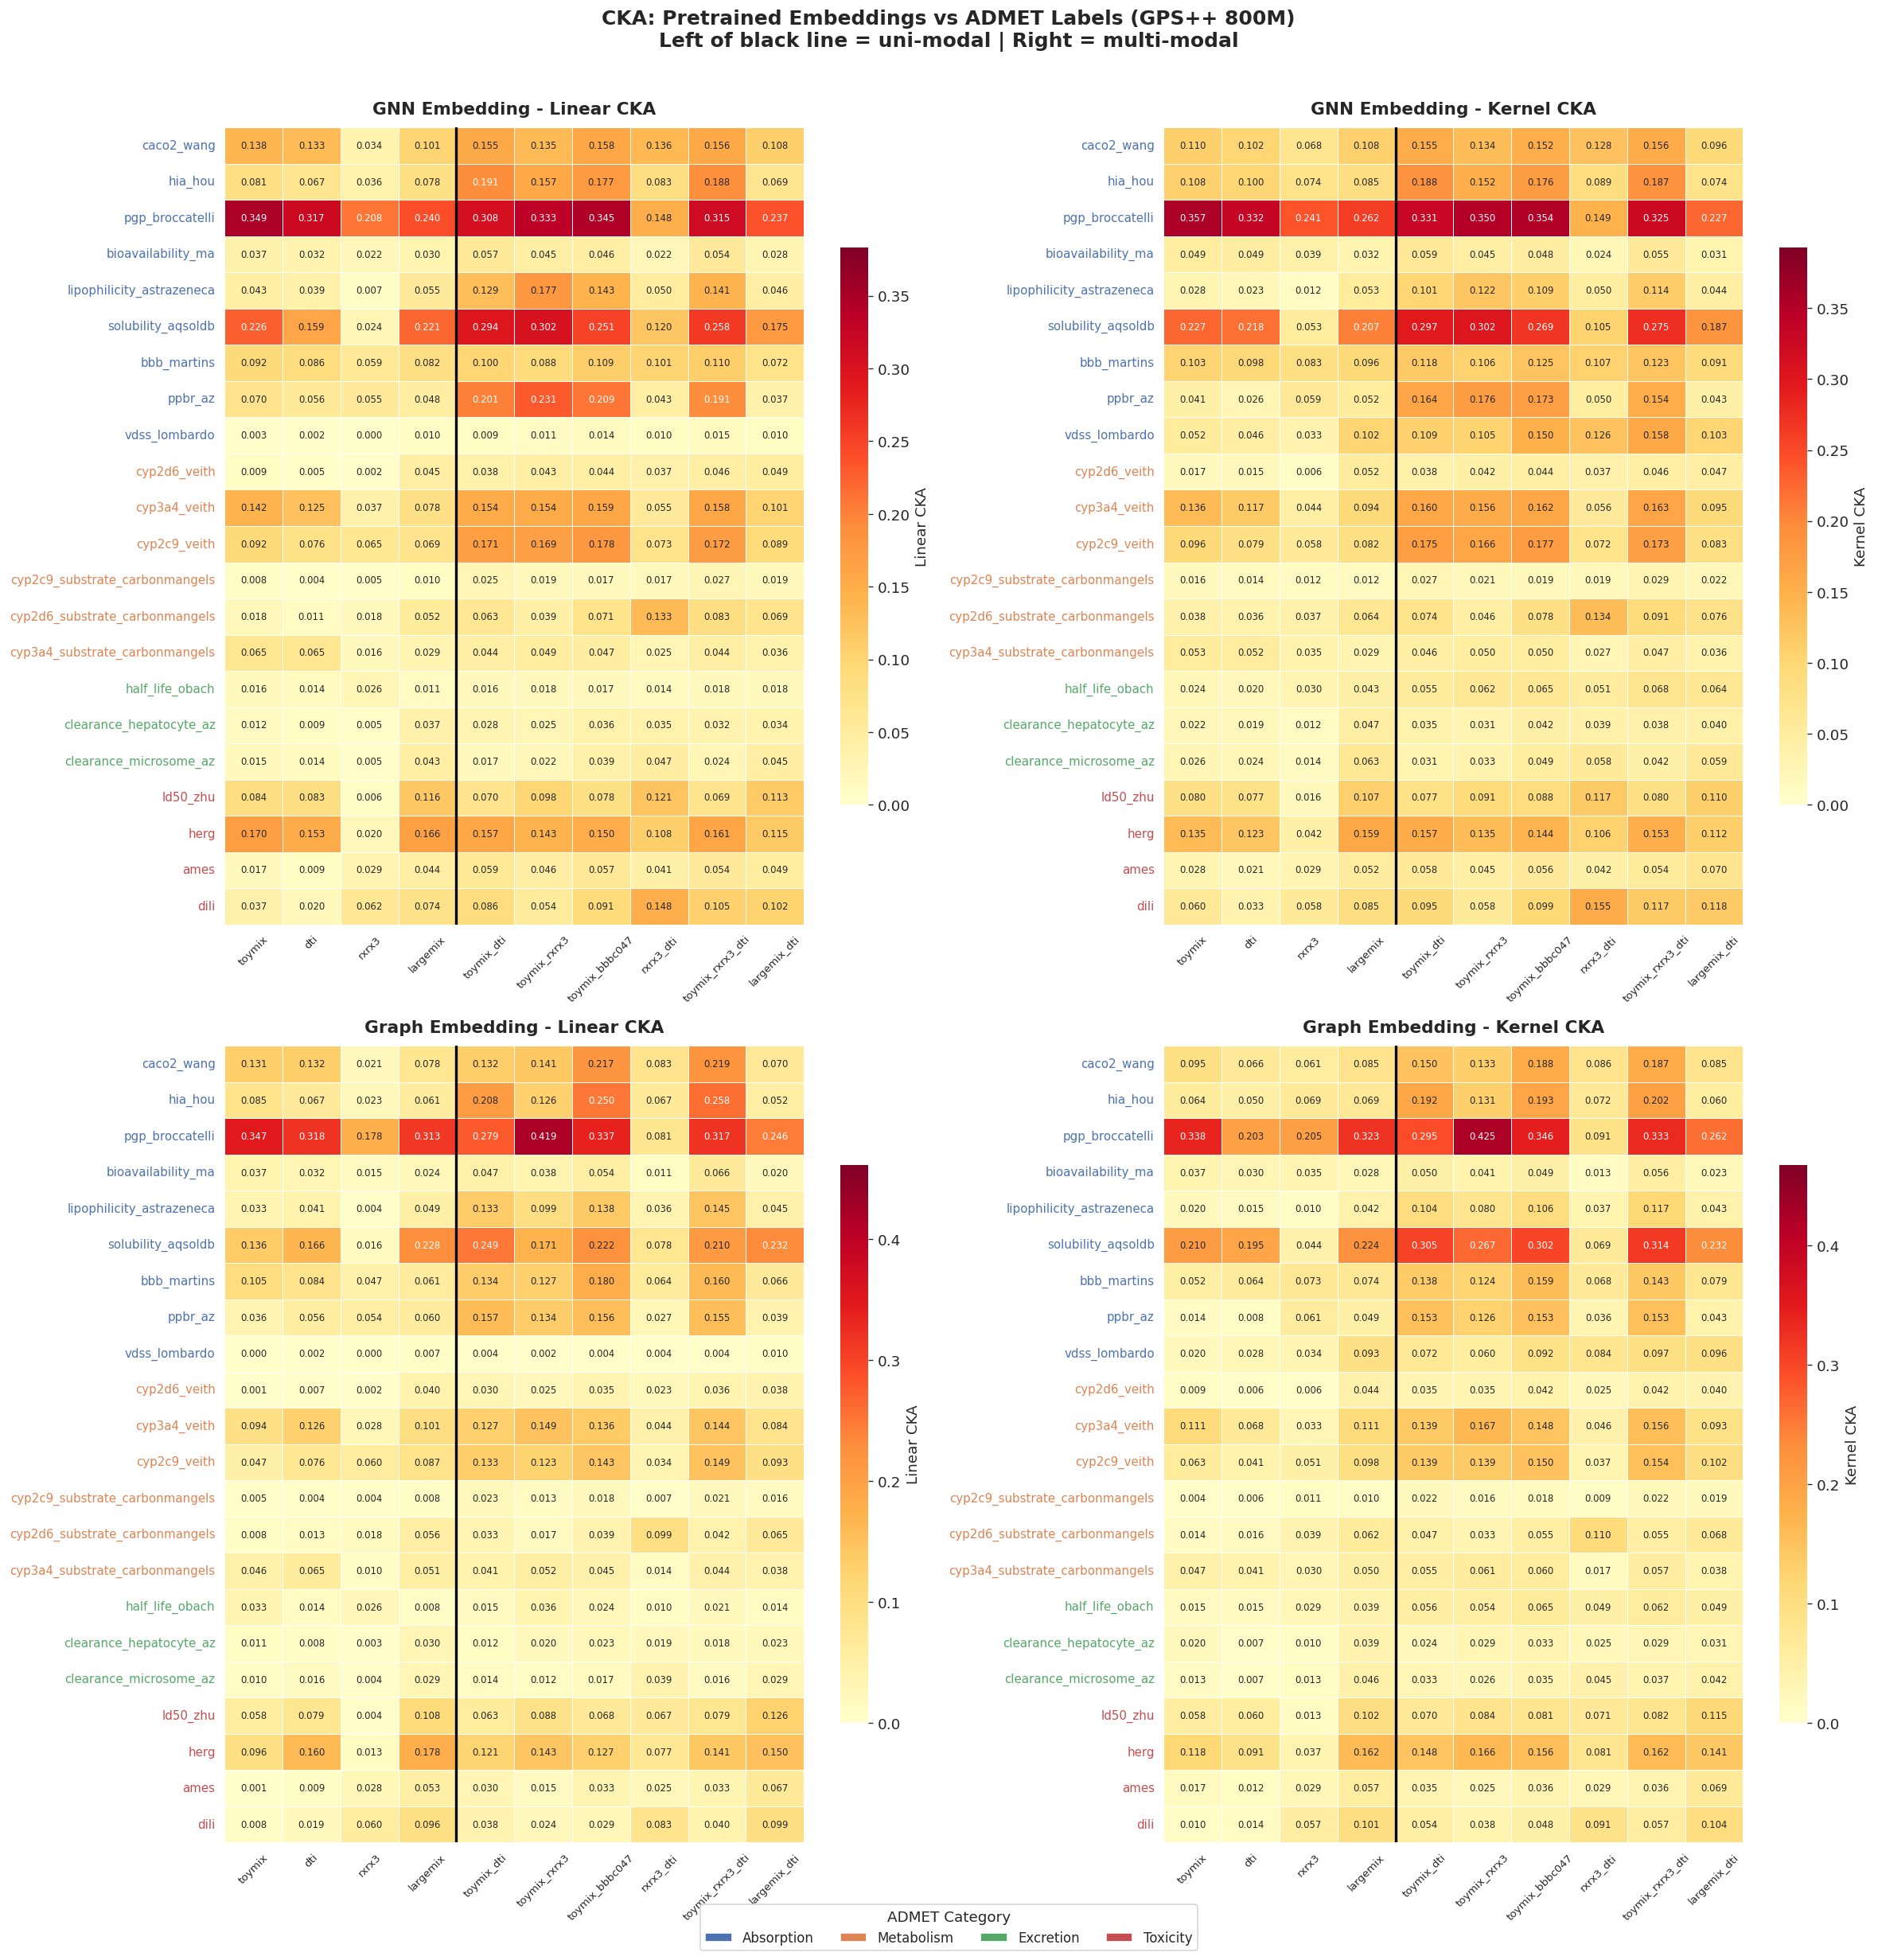

In [3]:
def plot_cka_heatmap(df, emb_type, cka_type, ax, title, ckpt_order=CKPT_ALL):
    sub = df[df["embedding"] == emb_type]
    col = f"{cka_type}_cka"
    pivot = sub.pivot(index="task", columns="checkpoint", values=col)
    pivot = pivot.reindex(index=TASK_ORDER, columns=ckpt_order)
    sns.heatmap(
        pivot, ax=ax, annot=True, fmt=".3f", cmap="YlOrRd",
        vmin=0, vmax=max(0.3, pivot.max().max() * 1.1),
        linewidths=0.5, linecolor="white", annot_kws={"fontsize": 7},
        cbar_kws={"label": f"{cka_type.title()} CKA", "shrink": 0.7},
    )
    ax.set_title(title, fontsize=13, fontweight="bold", pad=10)
    ax.set_ylabel(""); ax.set_xlabel("")
    color_yticks(ax)
    ax.tick_params(axis="x", labelsize=8, rotation=45)
    # Divider between uni-modal and multi-modal
    if len(ckpt_order) > len(CKPT_UNI):
        ax.axvline(x=len(CKPT_UNI), color="black", linewidth=2)
    return pivot


fig, axes = plt.subplots(2, 2, figsize=(20, 20))
plot_cka_heatmap(df, "gnn", "linear", axes[0, 0], "GNN Embedding - Linear CKA")
plot_cka_heatmap(df, "gnn", "kernel", axes[0, 1], "GNN Embedding - Kernel CKA")
plot_cka_heatmap(df, "graph", "linear", axes[1, 0], "Graph Embedding - Linear CKA")
plot_cka_heatmap(df, "graph", "kernel", axes[1, 1], "Graph Embedding - Kernel CKA")

legend_elements = [matplotlib.patches.Patch(facecolor=c, label=cat)
                   for cat, c in CATEGORY_COLORS.items()]
fig.legend(handles=legend_elements, loc="lower center", ncol=4, fontsize=10,
           title="ADMET Category", bbox_to_anchor=(0.5, -0.01))
fig.suptitle("CKA: Pretrained Embeddings vs ADMET Labels (GPS++ 800M)\n"
             "Left of black line = uni-modal | Right = multi-modal",
             fontsize=15, fontweight="bold", y=1.01)
fig.tight_layout()
fig.savefig("../results/cka_analysis/cka_heatmaps_all.png", dpi=150, bbox_inches="tight")
plt.show()

## 1b. Data Baseline: Raw Features vs Model Embeddings

Compares raw atom-feature embeddings (no model, mean-pooled) against all model embeddings.
Shows how much the pretrained models improve alignment with ADMET labels over raw featurization.

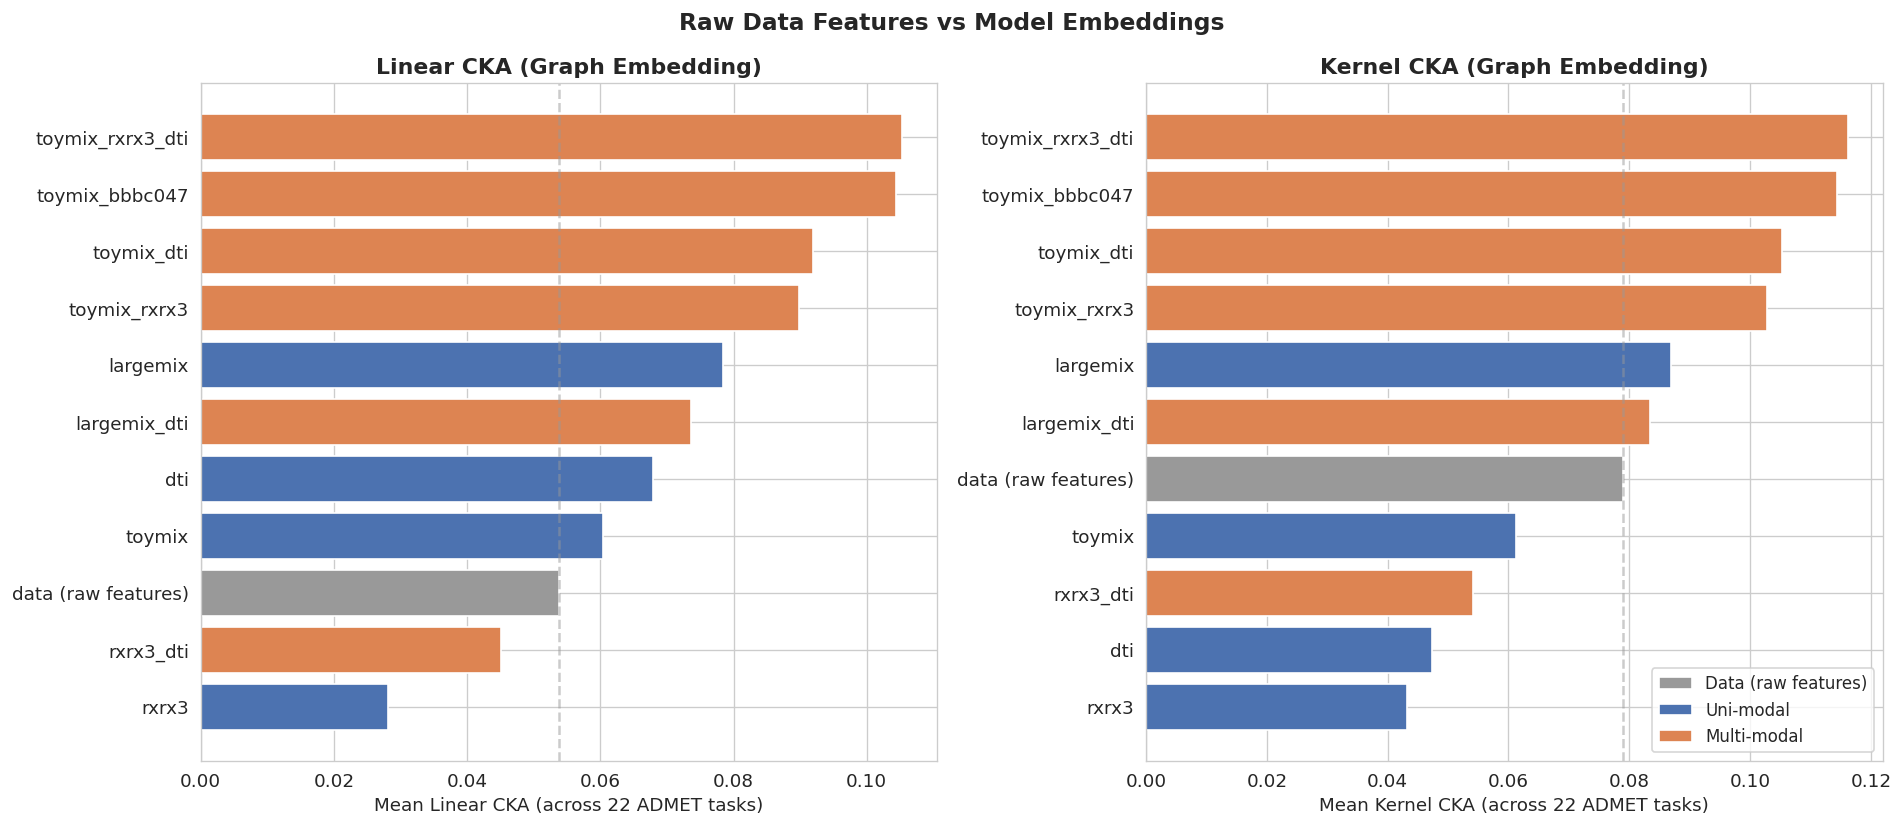

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, cka_type in zip(axes, ["linear", "kernel"]):
    col = f"{cka_type}_cka"

    # Data baseline (single bar per task)
    data_vals = df_data.set_index("task")[col].reindex(TASK_ORDER[::-1])

    # Model means per checkpoint, grouped by embedding type (use graph)
    model_graph = df_model[df_model["embedding"] == "graph"]
    model_means = (
        model_graph.groupby("checkpoint")[col].mean()
        .reindex(CKPT_ALL)
    )

    # Horizontal bar: data baseline + all model checkpoints
    all_means = pd.concat([
        pd.Series({"data (raw features)": data_vals.mean()}),
        model_means,
    ])
    all_means = all_means.sort_values()

    colors = ["#999999" if "data" in str(k) else
              "#4C72B0" if k in CKPT_UNI else "#DD8452"
              for k in all_means.index]
    ax.barh(all_means.index, all_means.values, color=colors, edgecolor="white")
    ax.set_xlabel(f"Mean {cka_type.title()} CKA (across 22 ADMET tasks)")
    ax.set_title(f"{cka_type.title()} CKA (Graph Embedding)", fontweight="bold")
    ax.axvline(x=data_vals.mean(), color="#999999", linestyle="--", alpha=0.5)

legend_elements = [
    matplotlib.patches.Patch(facecolor="#999999", label="Data (raw features)"),
    matplotlib.patches.Patch(facecolor="#4C72B0", label="Uni-modal"),
    matplotlib.patches.Patch(facecolor="#DD8452", label="Multi-modal"),
]
axes[1].legend(handles=legend_elements, fontsize=10, loc="lower right")

fig.suptitle("Raw Data Features vs Model Embeddings",
             fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig("../results/cka_analysis/cka_data_vs_model.png", dpi=150, bbox_inches="tight")
plt.show()


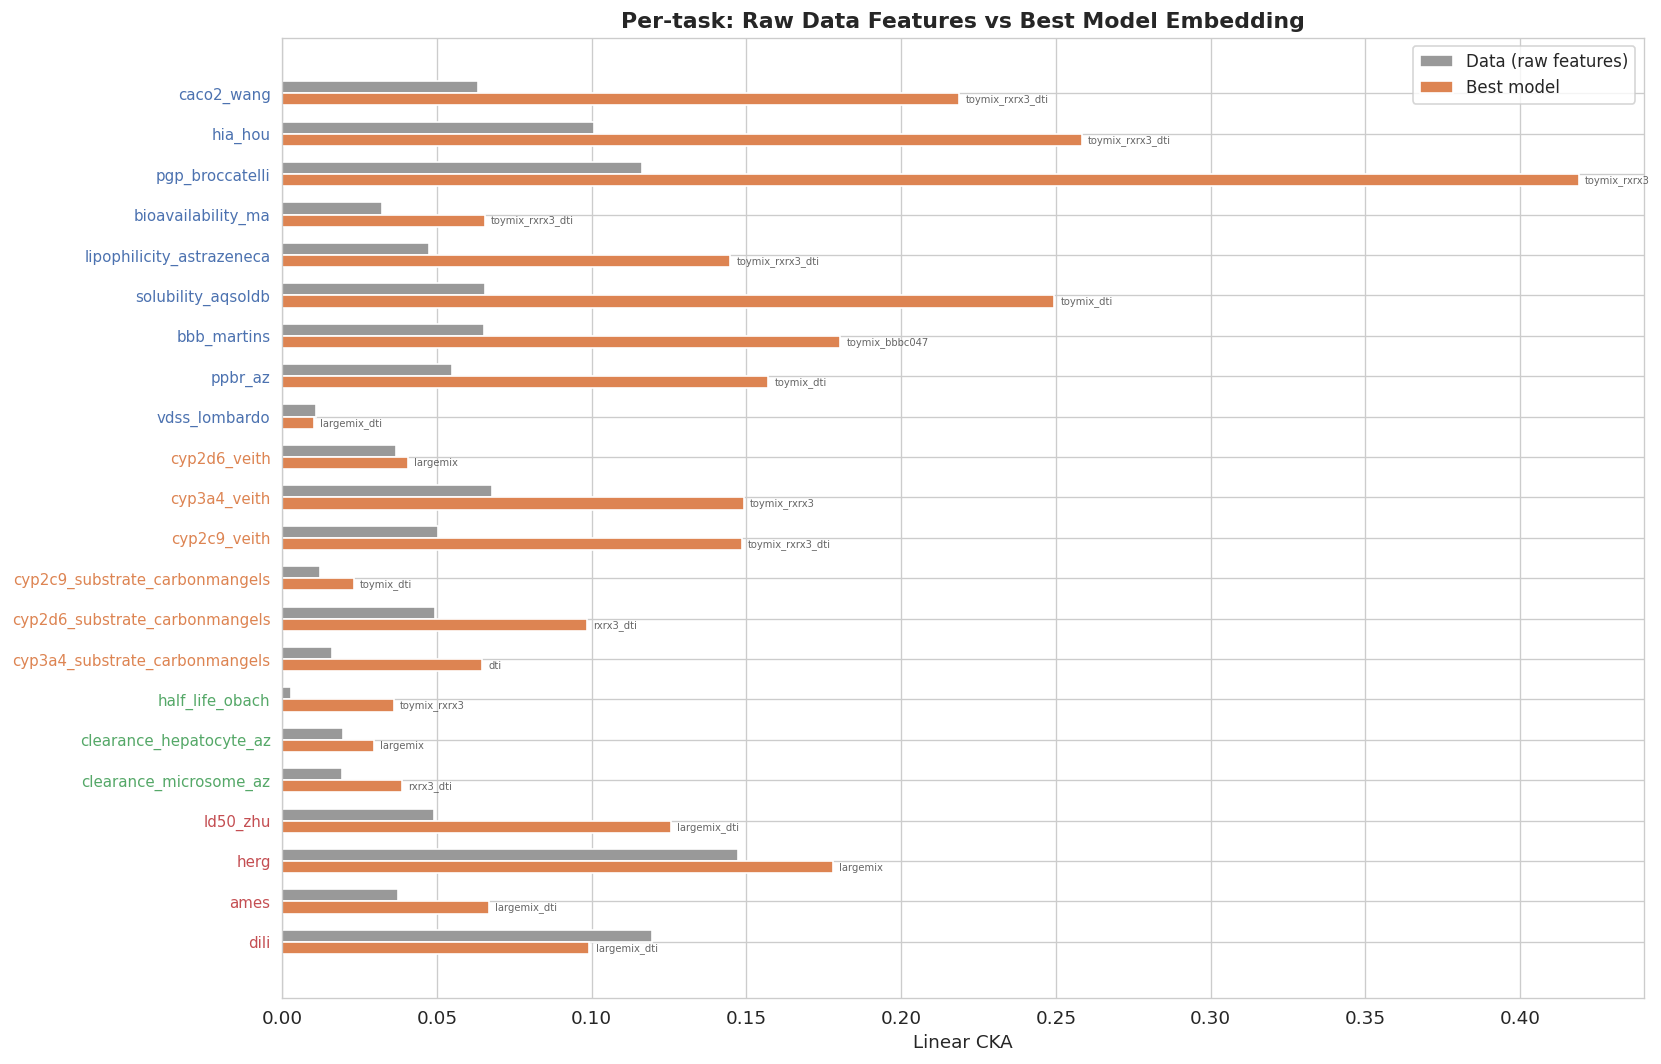

In [5]:
# Per-task comparison: data baseline vs best model
fig, ax = plt.subplots(figsize=(14, 9))

data_vals = df_data.set_index("task")["linear_cka"].reindex(TASK_ORDER[::-1])
model_graph = df_model[df_model["embedding"] == "graph"]
best_model = model_graph.loc[model_graph.groupby("task")["linear_cka"].idxmax()]
best_vals = best_model.set_index("task")["linear_cka"].reindex(TASK_ORDER[::-1])
best_names = best_model.set_index("task")["checkpoint"].reindex(TASK_ORDER[::-1])

y = np.arange(len(TASK_ORDER))
ax.barh(y + 0.15, data_vals.values, 0.3, label="Data (raw features)", color="#999999")
ax.barh(y - 0.15, best_vals.values, 0.3, label="Best model", color="#DD8452")

# Annotate with best model name
for i, (task, name) in enumerate(best_names.items()):
    ax.annotate(name, (best_vals[task] + 0.002, i - 0.15),
                fontsize=6, va="center", alpha=0.7)

ax.set_yticks(y)
ax.set_yticklabels(data_vals.index, fontsize=8)
color_yticks(ax)
ax.set_xlabel("Linear CKA")
ax.legend(fontsize=10)
ax.set_title("Per-task: Raw Data Features vs Best Model Embedding",
             fontweight="bold")

fig.tight_layout()
fig.savefig("../results/cka_analysis/cka_data_vs_best_model.png", dpi=150, bbox_inches="tight")
plt.show()


## 2. Uni-modal vs Multi-modal: Mean CKA Comparison

Does multi-modal pretraining produce embeddings more aligned with ADMET tasks?

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, emb_type in zip(axes, ["gnn", "graph"]):
    sub = df[df["embedding"] == emb_type]
    means = (
        sub.groupby(["modality", "checkpoint"])["linear_cka"]
        .mean().reset_index()
        .sort_values("linear_cka", ascending=True)
    )

    colors = ["#4C72B0" if m == "uni-modal" else "#DD8452"
              for m in means["modality"]]
    ax.barh(means["checkpoint"], means["linear_cka"], color=colors, edgecolor="white")
    ax.set_xlabel("Mean Linear CKA (across 22 ADMET tasks)")
    ax.set_title(f"{emb_type.upper()} Embedding", fontweight="bold")

legend_elements = [
    matplotlib.patches.Patch(facecolor="#4C72B0", label="Uni-modal"),
    matplotlib.patches.Patch(facecolor="#DD8452", label="Multi-modal"),
]
axes[1].legend(handles=legend_elements, fontsize=10)

fig.suptitle("Mean CKA: Uni-modal vs Multi-modal Pretraining",
             fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig("../results/cka_analysis/cka_uni_vs_multi.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Grouped Bar Charts by ADMET Category

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

for idx, (emb_type, cka_type) in enumerate(
    [("gnn", "linear"), ("gnn", "kernel"), ("graph", "linear"), ("graph", "kernel")]
):
    ax = axes[idx // 2, idx % 2]
    sub = df[df["embedding"] == emb_type]
    col = f"{cka_type}_cka"

    cat_means = (
        sub.groupby(["category", "checkpoint"])[col]
        .mean().unstack("checkpoint")
        .reindex(columns=CKPT_ALL)
        .reindex(["Absorption", "Metabolism", "Excretion", "Toxicity"])
    )

    cat_means.plot(kind="bar", ax=ax, width=0.85, edgecolor="white", linewidth=0.5)
    ax.set_title(f"{emb_type.upper()} - {cka_type.title()} CKA", fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel(f"{cka_type.title()} CKA")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.legend(title="Pretrain", fontsize=7, ncol=2)
    ax.set_ylim(bottom=0)

fig.suptitle("Mean CKA by ADMET Category", fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig("../results/cka_analysis/cka_by_category.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Per-task Best Checkpoint (Linear CKA, graph embedding)

In [ ]:
fig, ax = plt.subplots(figsize=(12, 9))

sub = df[(df["embedding"] == "graph")]
pivot = sub.pivot(index="task", columns="checkpoint", values="linear_cka")
pivot = pivot.reindex(index=TASK_ORDER[::-1], columns=CKPT_ALL)

y = np.arange(len(pivot))
n_ckpts = len(CKPT_ALL)
height = 0.8 / n_ckpts
cmap = plt.cm.get_cmap("tab10", n_ckpts)

for j, ckpt in enumerate(CKPT_ALL):
    ax.barh(y + j * height, pivot[ckpt], height, label=ckpt,
            color=cmap(j), alpha=0.85)

ax.set_yticks(y + height * n_ckpts / 2)
ax.set_yticklabels(pivot.index, fontsize=8)
ax.set_xlabel("Linear CKA")
ax.set_title("Graph Embedding - Linear CKA per Task", fontweight="bold")
ax.legend(title="Pretrain", fontsize=8, ncol=2, loc="lower right")
color_yticks(ax)

fig.tight_layout()
fig.savefig("../results/cka_analysis/cka_per_task.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Regression vs Classification Tasks

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, emb_type in zip(axes, ["gnn", "graph"]):
    sub = df[df["embedding"] == emb_type]
    means = (
        sub.groupby(["task_type", "checkpoint"])["linear_cka"]
        .mean().unstack("checkpoint")
        .reindex(columns=CKPT_ALL)
        .reindex(["regression", "classification"])
    )
    means.plot(kind="bar", ax=ax, width=0.85, edgecolor="white")
    ax.set_xticklabels(["Regression", "Classification"], rotation=0)
    ax.set_ylabel("Mean Linear CKA")
    ax.set_title(f"{emb_type.upper()} Embedding", fontweight="bold")
    ax.legend(title="Pretrain", fontsize=7, ncol=2)
    ax.set_ylim(bottom=0)

fig.suptitle("CKA: Regression vs Classification Tasks",
             fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig("../results/cka_analysis/cka_reg_vs_cls.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Multi-modal Gain: CKA Difference vs Base Model

For each multi-modal checkpoint, compute the CKA gain over its base uni-modal component.

In [ ]:
# Define base model for each multi-modal checkpoint
MULTI_BASE = {
    "toymix_dti": "toymix",
    "toymix_rxrx3": "toymix",
    "toymix_bbbc047": "toymix",
    "rxrx3_dti": "rxrx3",
    "toymix_rxrx3_dti": "toymix",
    "largemix_dti": "largemix",
}

gains = []
for emb_type in ["gnn", "graph"]:
    sub = df[df["embedding"] == emb_type]
    pivot = sub.pivot(index="task", columns="checkpoint", values="linear_cka")
    for multi, base in MULTI_BASE.items():
        if multi in pivot.columns and base in pivot.columns:
            diff = pivot[multi] - pivot[base]
            for task, d in diff.items():
                gains.append({"multi": multi, "base": base,
                              "task": task, "category": task_to_cat.get(task, ""),
                              "embedding": emb_type, "cka_gain": d})

df_gains = pd.DataFrame(gains)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, emb_type in zip(axes, ["gnn", "graph"]):
    sub = df_gains[df_gains["embedding"] == emb_type]
    mean_gains = sub.groupby("multi")["cka_gain"].mean().sort_values()

    colors = ["#55A868" if v >= 0 else "#C44E52" for v in mean_gains]
    ax.barh(mean_gains.index, mean_gains.values, color=colors, edgecolor="white")
    ax.axvline(x=0, color="black", linewidth=0.8)
    ax.set_xlabel("Mean Linear CKA gain over base model")
    ax.set_title(f"{emb_type.upper()} Embedding", fontweight="bold")

fig.suptitle("Multi-modal CKA Gain vs Uni-modal Base",
             fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig("../results/cka_analysis/cka_multimodal_gain.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Multi-modal Gain by ADMET Category

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, (multi, base) in enumerate(MULTI_BASE.items()):
    ax = axes[idx]
    sub = df_gains[(df_gains["multi"] == multi) & (df_gains["embedding"] == "graph")]
    cat_gains = sub.groupby("category")["cka_gain"].mean()
    cat_gains = cat_gains.reindex(["Absorption", "Metabolism", "Excretion", "Toxicity"])

    colors = ["#55A868" if v >= 0 else "#C44E52" for v in cat_gains]
    ax.bar(cat_gains.index, cat_gains.values, color=colors, edgecolor="white")
    ax.axhline(y=0, color="black", linewidth=0.8)
    ax.set_title(f"{multi} vs {base}", fontweight="bold", fontsize=10)
    ax.set_ylabel("CKA gain")
    ax.tick_params(axis="x", labelsize=8, rotation=30)

fig.suptitle("Multi-modal CKA Gain by ADMET Category (Graph Embedding, Linear CKA)",
             fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig("../results/cka_analysis/cka_gain_by_category.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. GNN vs Graph Embedding Comparison

In [ ]:
n_ckpts = len(CKPT_ALL)
ncols = min(5, n_ckpts)
nrows = (n_ckpts + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows))
axes = np.atleast_2d(axes).flatten()

for i, ckpt in enumerate(CKPT_ALL):
    ax = axes[i]
    sub = df[df["checkpoint"] == ckpt]
    gnn_vals = sub[sub["embedding"] == "gnn"].set_index("task")["linear_cka"]
    graph_vals = sub[sub["embedding"] == "graph"].set_index("task")["linear_cka"]
    common = gnn_vals.index.intersection(graph_vals.index)

    cats = [task_to_cat.get(t, "Unknown") for t in common]
    colors = [CATEGORY_COLORS.get(c, "gray") for c in cats]

    ax.scatter(gnn_vals[common], graph_vals[common], c=colors, s=40, alpha=0.8, edgecolor="white")
    lims = [0, max(gnn_vals[common].max(), graph_vals[common].max()) * 1.15]
    ax.plot(lims, lims, "--", color="gray", alpha=0.5, linewidth=1)
    ax.set_xlabel("GNN (Linear CKA)", fontsize=9)
    ax.set_ylabel("Graph (Linear CKA)", fontsize=9)
    ax.set_title(ckpt, fontweight="bold", fontsize=10)
    ax.set_xlim(left=0); ax.set_ylim(bottom=0)

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

legend_elements = [matplotlib.patches.Patch(facecolor=c, label=cat)
                   for cat, c in CATEGORY_COLORS.items()]
fig.legend(handles=legend_elements, loc="lower center", ncol=4, fontsize=10,
           bbox_to_anchor=(0.5, -0.03))
fig.suptitle("GNN vs Graph Embedding: Linear CKA", fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig("../results/cka_analysis/cka_gnn_vs_graph.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Summary Statistics

In [ ]:
print("=" * 80)
print("SUMMARY: Mean CKA across all 22 ADMET tasks")
print("=" * 80)

# Data baseline
data_mean = df_data["linear_cka"].mean()
data_kmean = df_data["kernel_cka"].mean()
print(f"\nData baseline (raw features): linear={data_mean:.4f}, kernel={data_kmean:.4f}")

summary = (
    df_model.groupby(["embedding", "modality", "checkpoint"])[["linear_cka", "kernel_cka"]]
    .agg(["mean", "std"]).round(4)
)
summary.columns = [f"{c[0]}_{c[1]}" for c in summary.columns]
print("\n" + summary.to_string())

print("\n")
print("=" * 80)
print("Best checkpoint per task (Linear CKA, graph embedding)")
print("=" * 80)

graph_lin = df_model[df_model["embedding"] == "graph"]
best = graph_lin.loc[graph_lin.groupby("task")["linear_cka"].idxmax()]
wins = best["checkpoint"].value_counts()
print(f"\nWin counts: {dict(wins)}")
print(f"\nBest per task:")
for _, row in best.sort_values("category").iterrows():
    data_cka = df_data[df_data["task"]==row["task"]]["linear_cka"].values[0]
    gain = row["linear_cka"] - data_cka
    tag = "*" if row["modality"] == "multi-modal" else " "
    print(f" {tag} [{row['category']:12s}] {row['task']:35s} "
          f"-> {row['checkpoint']:20s} ({row['linear_cka']:.4f}, gain={gain:+.4f})")
print("\n(* = multi-modal checkpoint, gain = improvement over raw data baseline)")
